In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager
from src.evaluation import Evaluator

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1


config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',    
    )       
data_orchestrator = DataOrchestrator(config).build()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

graphdataloader_1  = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()

graphdataloader_2  = GraphDataLoaderManager(data_orchestrator).retrieve_dynamic_graph('dynamic_commuter1',timesteps = range(2002,2025), frequency='yearly').construct_dataloaders()

loading graphs: 100%|████████████████████████████████████████████████████████████████████████| 23/23 [00:00<00:00, 430.03it/s]



==                gatv2-id graph                ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))


Training epochs:  26%|██████████████████▏                                                    | 64/250 [03:35<10:27,  3.37s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4598


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 566.65it/s]

Test loss: 0.8187


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

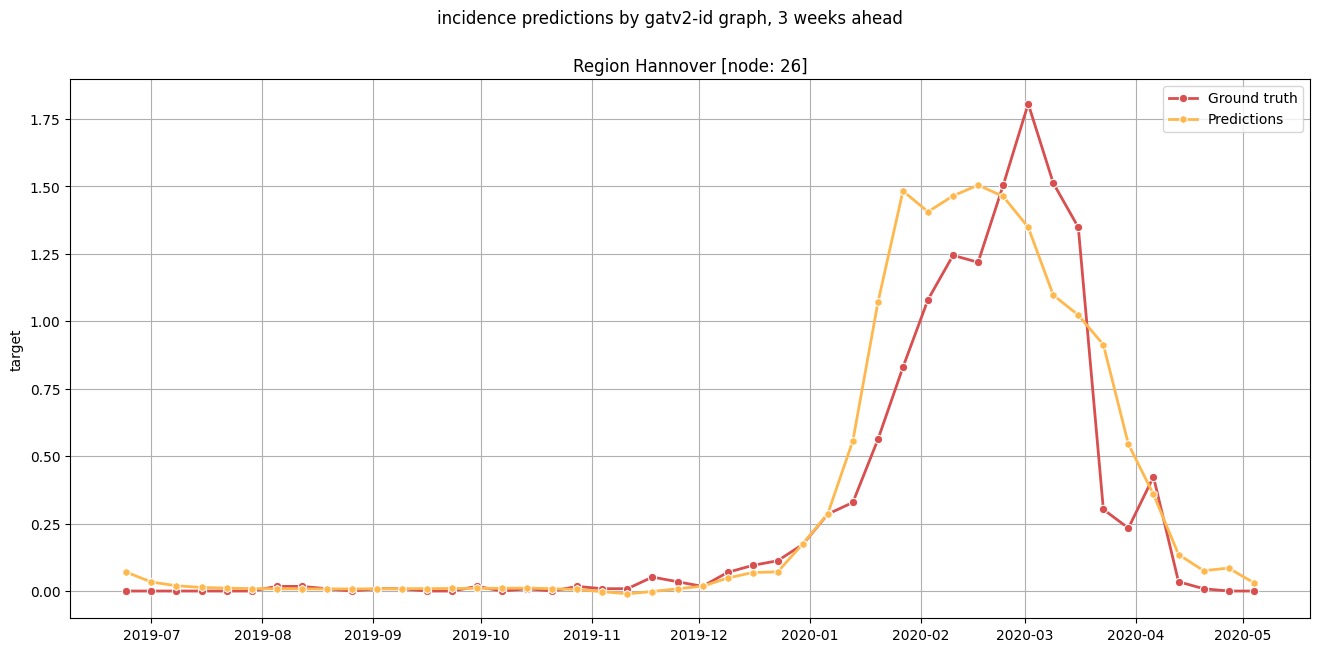

In [3]:
from src.models import GATv2Model

st1 = GATv2Model(graphdataloader_1, name = 'gatv2-id graph')
st1.set_model_hparams()
st1.set_global_hparams(**global_hparams)
st1.train(verbose = 0, show_loss=False)
st1.forecast('test')
st1.show_forecasts(26)


==           gatv2-dynamic_commuter1            ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2778), edge_weight=(2778,))


Training epochs:  32%|██████████████████████▍                                                | 79/250 [04:26<09:35,  3.37s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4558


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 534.54it/s]

Test loss: 0.7637


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

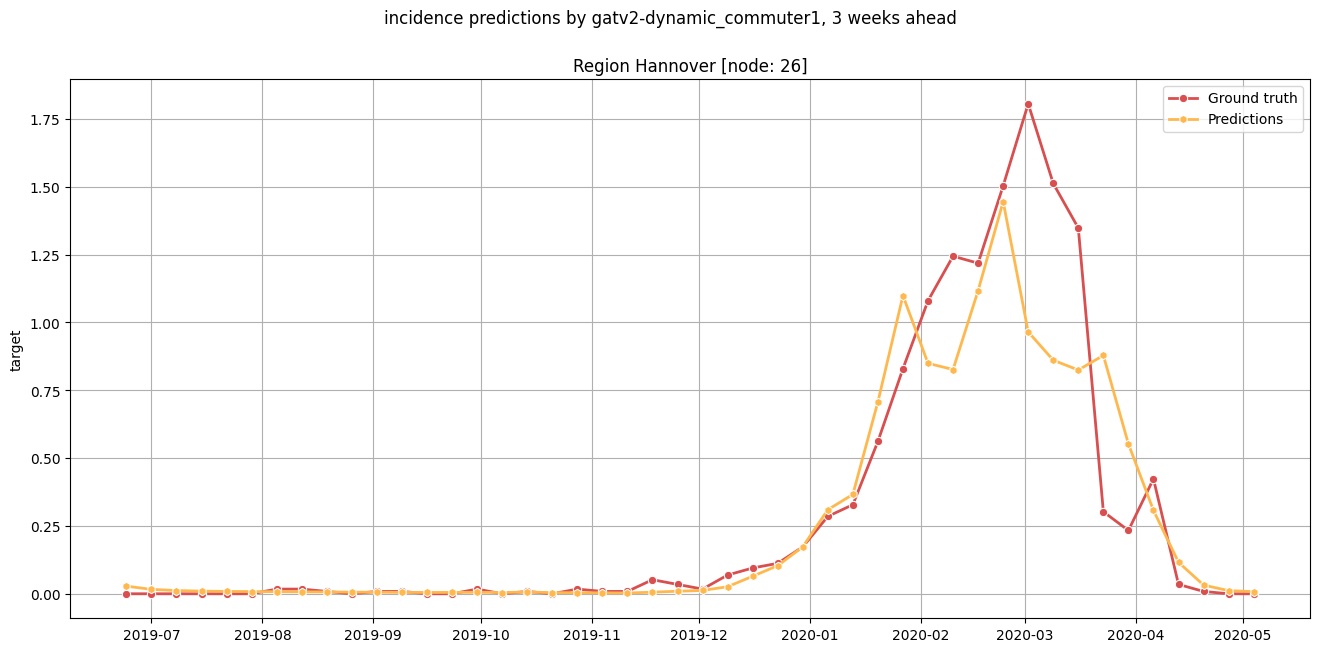

In [4]:
st2 = GATv2Model(graphdataloader_2, name = 'gatv2-dynamic_commuter1')
st2.set_model_hparams()
st2.set_global_hparams(**global_hparams)
st2.train(verbose = 0, show_loss=False)
st2.forecast('test')
st2.show_forecasts(26)

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.95it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


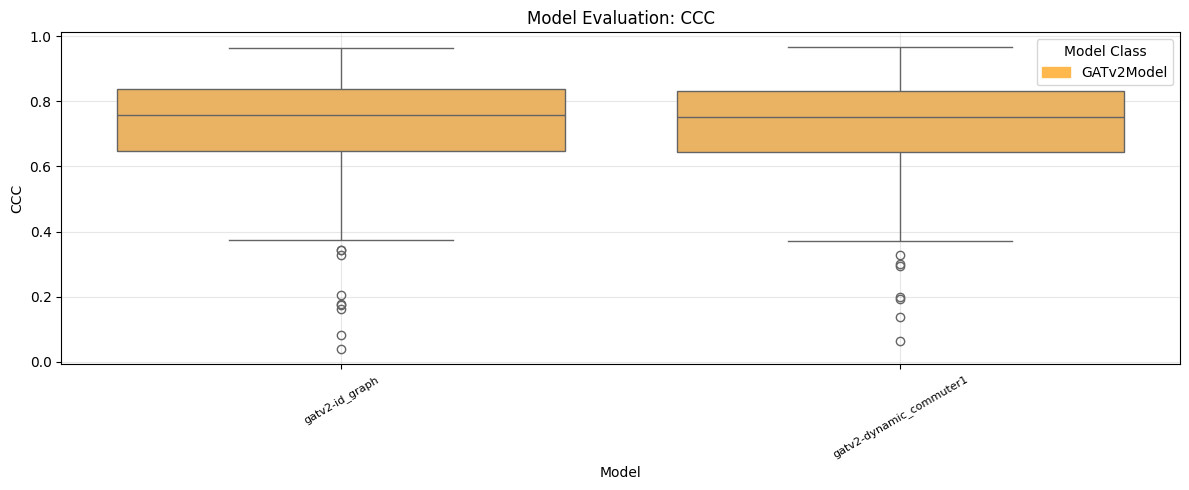

In [ ]:
evaling = Evaluator([st1, st2])
evaling.add_evaluation(0, 'test')


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


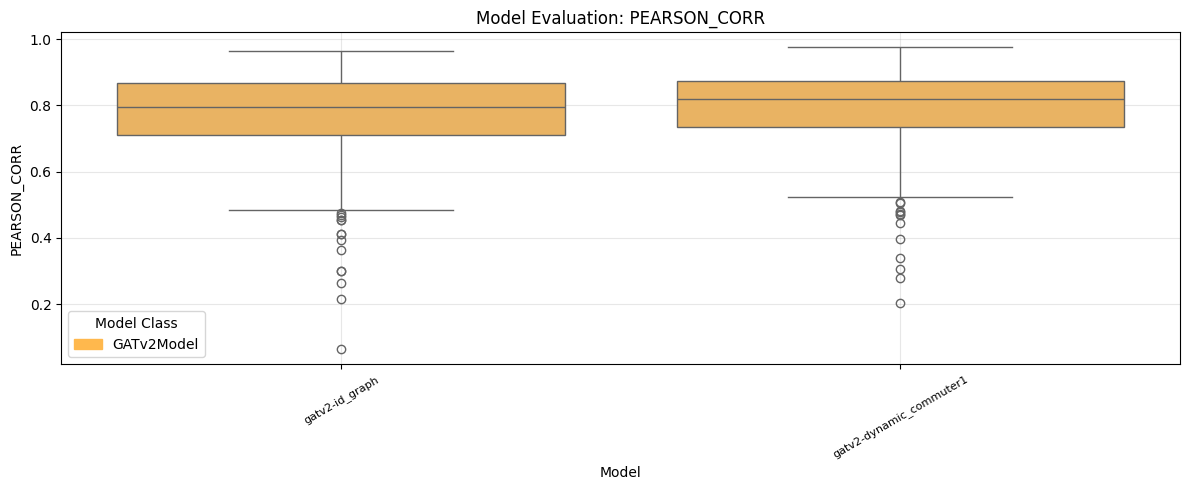

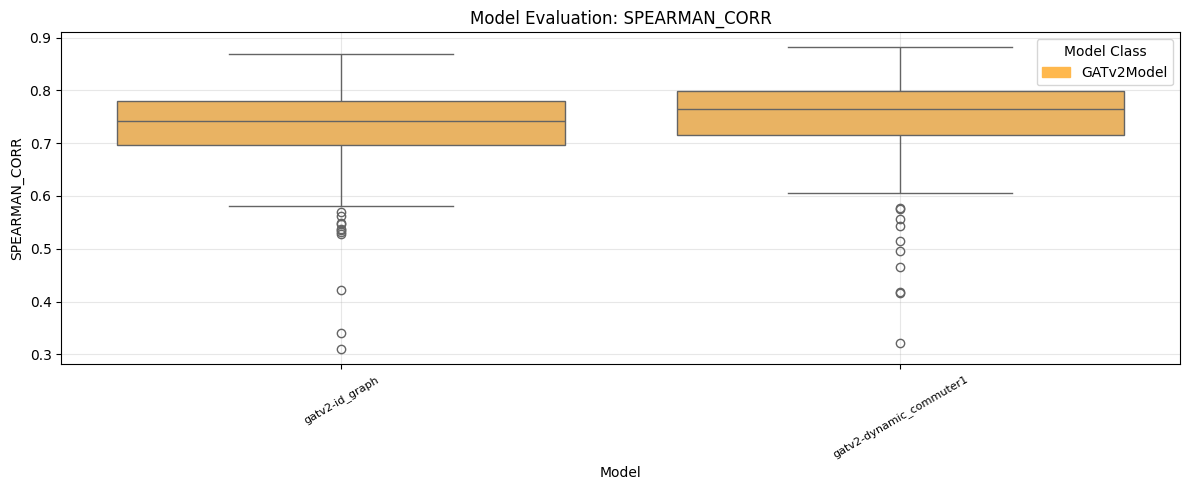

In [9]:

evaling.plotter.plot_metric('pearson_corr', horizon = 'horizon_0', plot_type='box')
evaling.plotter.plot_metric('spearman_corr', horizon = 'horizon_0', plot_type='box')